In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

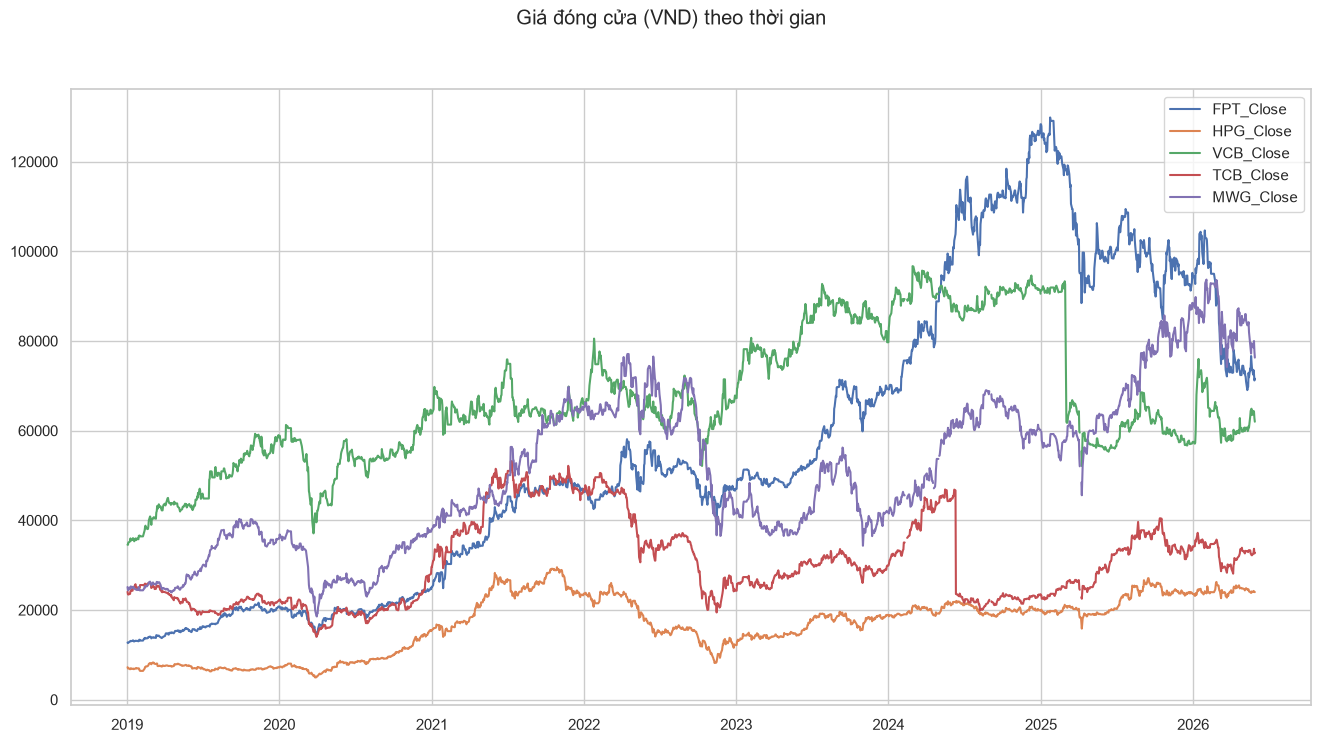

In [9]:
data = pd.read_excel(r'D:\StockPrice\data\VN5_Close_Volume.xlsx')
data = data.drop(data.index[0])

data.set_index('Date', inplace=True)
data.index = pd.to_datetime(data.index)

plt.figure(figsize=(16, 8))
plt.suptitle('Giá đóng cửa (VND) theo thời gian')
# Vẽ giá
for col in data.columns:
    if 'Close' in col:
        plt.plot(data.index, data[col], label=col)

plt.legend()

In [42]:
class Technical_Indicators:
    def __init__(self, data, close_col):
        self.data = data[[close_col]].copy()
        self.close_col = close_col
        self.data.dropna(subset=[self.close_col], inplace=True)
    
    # Đường trung bình dài hạn
    def add_sma(self, period=20):
        self.data[f'SMA_{period}'] = self.data[self.close_col].rolling(period).mean()
    
    # Đường trung bình ngắn hạn
    def add_ema(self, period=20):
        self.data[f'EMA_{period}'] = self.data[self.close_col].ewm(span=period, adjust=False).mean()

    # Chỉ số đo lực mua/bán 
    def add_rsi(self, period=14):
        delta = self.data[self.close_col].diff()
        
        gain = (delta.where(delta > 0, 0)).rolling(period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
        
        rsi = gain / loss
        self.data[f'RSI_{period}'] = 100 - (100 / (1 + rsi))
    
    # Chỉ báo động lượng và xu hướng
    def add_macd(self, fast=12, slow=26, signal=9):
        exp1 = self.data[self.close_col].ewm(span=fast, adjust=False).mean()
        exp2 = self.data[self.close_col].ewm(span=slow, adjust=False).mean()
        self.data['MACD'] = exp2 - exp1
        self.data['MACD_Signal'] = self.data['MACD'].ewm(span=signal, adjust=False).mean()
    
    # Đường biên trên và đường biên dưới
    def add_bolling_band(self, period=20, std_dev=2):
        sma = self.data[self.close_col].rolling(window=period).mean()
        rolling_std = self.data[self.close_col].rolling(window=period).std()
        self.data['BB_Up'] = sma + (rolling_std * std_dev)
        self.data['BB_Down'] = sma - (rolling_std * std_dev)
        
    # Tỷ suất sinh lời hằng ngày và biến động
    def add_return_and_volatility(self, period=20):
        self.data['Return'] = self.data[self.close_col].pct_change()
        self.data[f'Volatility_{period}'] = self.data['Return'].rolling(window=period).std() * np.sqrt(252)    
    
    def build_all_indicators(self):
        """Helper to generate all engineered features at once."""
        self.add_sma(20)
        self.add_sma(50)
        self.add_ema(20)
        self.add_rsi(14)
        self.add_macd()
        self.add_bolling_band(20)
        self.add_return_and_volatility(20)
        self.data.dropna(inplace=True)
        return self.data
    
class Strategy:
    def __init__(self, data):
        self.data = data
    
    def sma_cross_over(self, short_col='SMA_20', long_col='SMA_50'):
        self.data['Signal'] = 0.0
        self.data['Signal'] = np.where(self.data[short_col] > self.data[long_col], 1.0, 0.0)
        self.data['Postion'] = self.data['Signal'].diff()
        return self.data
    
class Back_Testing:
    def __init__(self, data, initial_capital):
        self.data = data
        self.initial_capital = initial_capital
        
    def run(self):
        # Shift(1) để tránh Look-Ahead Bias: Tín hiệu hôm nay sẽ quyết định lợi nhuận ngày mai
        self.data['Strategy_Return'] = self.data['Signal'].shift(1) * self.data['Return']
        
        # Tính toán lợi nhuận lũy kế
        self.data['Cumulative_Market_Returns'] = (1 + self.data['Return']).cumprod() * self.initial_capital
        self.data['Cumulative_Strategy_Returns'] = (1 + self.data['Strategy_Return']).cumprod() * self.initial_capital
        
        return self.calculate_metrics()
    
    def calculate_metrics(self):
        strat_returns = self.data['Strategy_Return'].dropna()
        if strat_returns.std() != 0:
            sharpe_ratio = (strat_returns.mean() / strat_returns.std()) * np.sqrt(252)
        else:
            sharpe_ratio = 0

        cum_returns = self.data['Cumulative_Strategy_Returns']
        running_max = cum_returns.cummax()
        drawdown = (cum_returns - running_max) / running_max
        max_drawdown = drawdown.min()
        
        total_return = (cum_returns.iloc[-1] - self.initial_capital) / self.initial_capital * 100

        print(f"Tổng lợi nhuận (Total Return): {total_return:.2f}%")
        print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
        print(f"Sụt giảm tối đa (Max Drawdown): {max_drawdown * 100:.2f}%\n")
        
        return total_return, sharpe_ratio, max_drawdown

    def plot_results(self, ticker_code, label):
        plt.figure(figsize=(12, 5))
        plt.plot(self.data.index, self.data['Cumulative_Market_Returns'], label='Mua & Nắm giữ (Buy & Hold)', color='gray', alpha=0.7)
        plt.plot(self.data.index, self.data['Cumulative_Strategy_Returns'], label=label, color='blue')
        plt.title(f'[{ticker_code}] Hiệu suất Chiến lược so với Thị trường')
        plt.ylabel('Giá trị danh mục (VND)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

Đang thực hiện back testing trên FPT
Tổng lợi nhuận (Total Return): -26.58%
Sharpe Ratio: -1.38
Sụt giảm tối đa (Max Drawdown): -30.36%



C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = 0.0
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = np.where(self.data[short_col] > self.data[long_col], 1.0, 0.0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

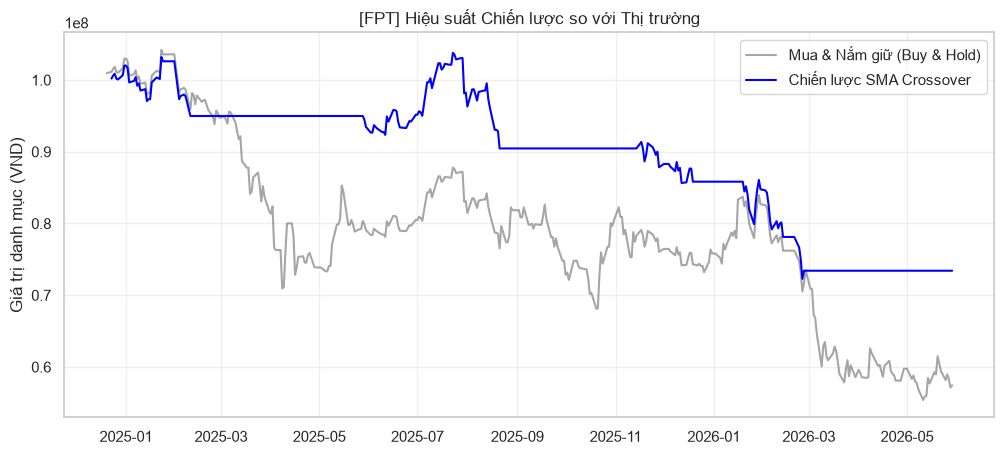

Đang thực hiện back testing trên HPG
Tổng lợi nhuận (Total Return): -4.90%
Sharpe Ratio: -0.03
Sụt giảm tối đa (Max Drawdown): -20.97%



C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = 0.0
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = np.where(self.data[short_col] > self.data[long_col], 1.0, 0.0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

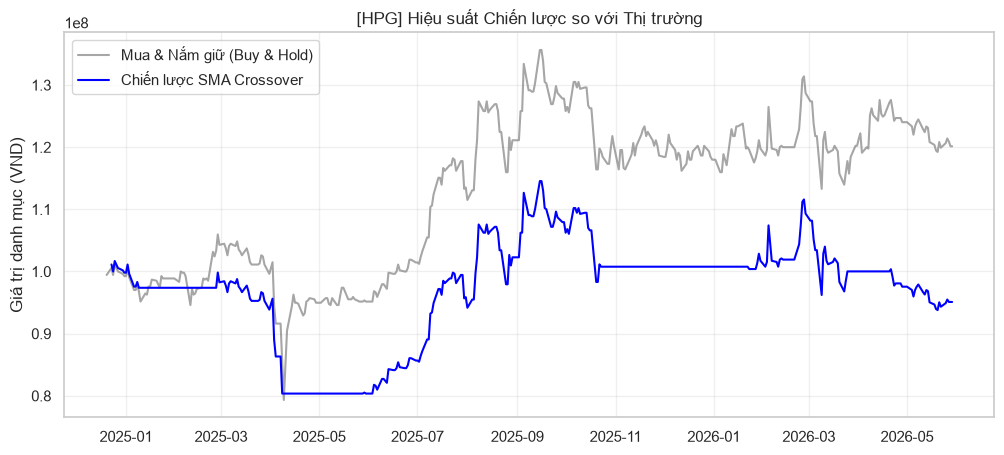

C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = 0.0
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = np.where(self.data[short_col] > self.data[long_col], 1.0, 0.0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

Đang thực hiện back testing trên VCB
Tổng lợi nhuận (Total Return): -36.56%
Sharpe Ratio: -0.78
Sụt giảm tối đa (Max Drawdown): -39.29%



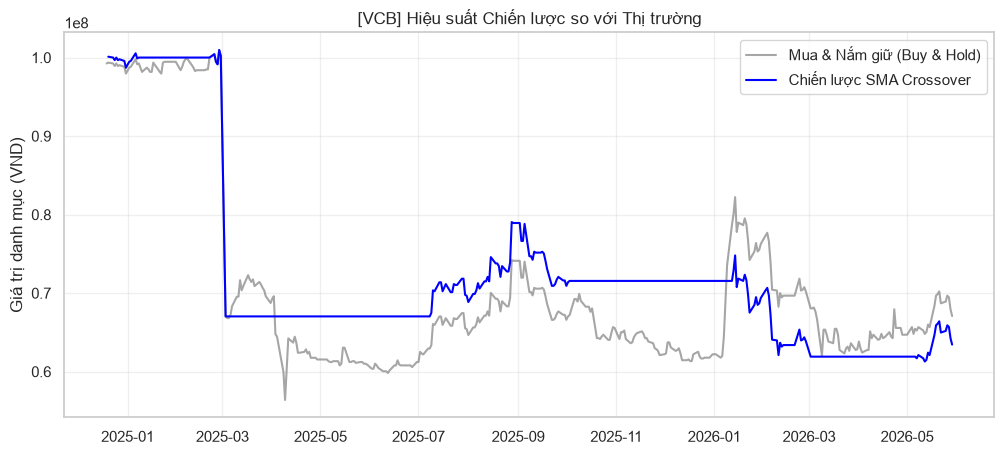

C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = 0.0
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = np.where(self.data[short_col] > self.data[long_col], 1.0, 0.0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

Đang thực hiện back testing trên TCB
Tổng lợi nhuận (Total Return): 27.96%
Sharpe Ratio: 0.76
Sụt giảm tối đa (Max Drawdown): -18.95%



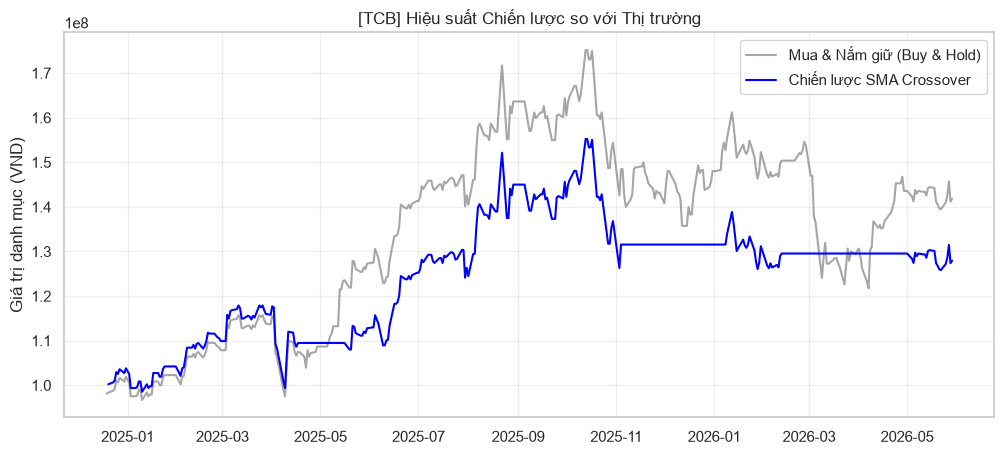

C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = 0.0
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['Signal'] = np.where(self.data[short_col] > self.data[long_col], 1.0, 0.0)
C:\Users\Admin\AppData\Local\Temp\ipykernel_24168\1957026216.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

Đang thực hiện back testing trên MWG
Tổng lợi nhuận (Total Return): -17.22%
Sharpe Ratio: -0.32
Sụt giảm tối đa (Max Drawdown): -27.20%



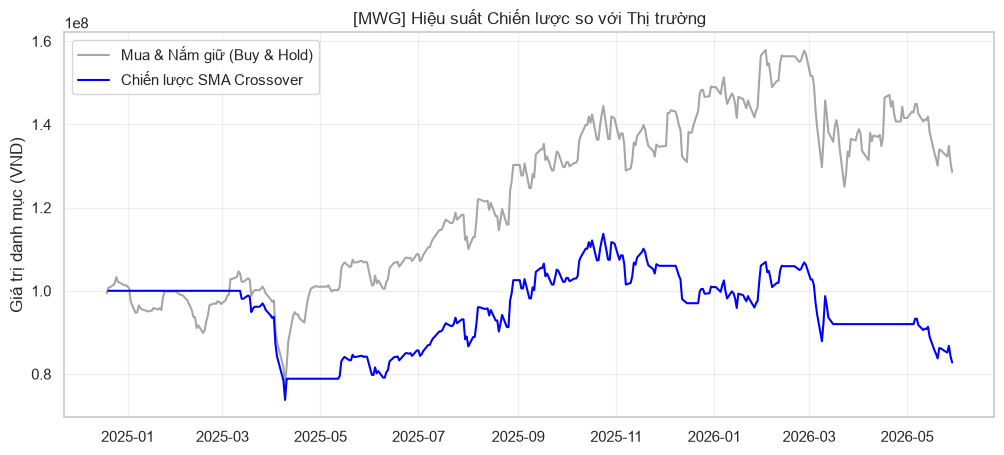

In [45]:
stock_codes = ['FPT', 'HPG', 'VCB', 'TCB', 'MWG']

for code in stock_codes:
        
        technical_indicators = Technical_Indicators(data=data, close_col=f'{code}_Close')
        df_indicators = technical_indicators.build_all_indicators()
        
        train_size = int(len(df_indicators) * 0.8)
        
        train_data = df_indicators[:train_size]
        test_data = df_indicators[train_size:]
        
        strategy = Strategy(test_data)
        df_signals = strategy.sma_cross_over(short_col='SMA_20', long_col='SMA_50')
        
        print(f'Đang thực hiện back testing trên {code}')
        back_testing = Back_Testing(df_signals, initial_capital=100000000)
        back_testing.run()
        back_testing.plot_results(code, 'Chiến lược SMA Crossover')

### Machine Learning Stragety

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

In [ ]:
class MLStrategy:
    def __init__(self, data):
        self.data = data.copy()
        self.model = None

    def prepare_data(self, feature_cols):
        self.data['Target'] = np.where(self.data['Return'].shift(-5) > 0, 1, 0)
        
        # Xóa các dòng NaN
        ml_data = self.data.dropna().copy()
        
        X = ml_data[feature_cols]
        y = ml_data['Target']
        
        # Chia dữ liệu: 80% Train, 20% Test 
        train_size = int(len(ml_data) * 0.8)
        
        X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
        X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        return X_train_scaled, X_test_scaled, y_train, y_test, ml_data, train_size

    def run_xgboost(self, feature_cols):
        
        X_train, X_test, y_train, y_test, ml_data, train_size = self.prepare_data(feature_cols)
        
        # Khởi tạo mô hình XGBoost
        self.model = xgb.XGBClassifier(
            n_estimators=1000,           # Đặt số lượng cây lớn
            max_depth=3,                 # Giữ độ sâu thấp chống Overfitting
            learning_rate=0.05, 
            random_state=42,    
        )
        
        # Huấn luyện mô hình
        self.model.fit(
            X_train, y_train,
            verbose=False                  
        )
        
        predictions = self.model.predict(X_test)
        
        # Lúc này ml_data đã được định nghĩa ở đầu hàm nên dòng dưới sẽ CHẠY MƯỢT MÀ
        ml_data['Signal'] = 0.0 
        
        # Chèn kết quả dự đoán vào đúng vị trí của tập Test (từ train_size trở đi)
        signal_col_idx = ml_data.columns.get_loc('Signal')
        ml_data.iloc[train_size:, signal_col_idx] = predictions
        
        # Trích xuất và trả về dữ liệu Test để chạy Backtester thực tế
        test_data = ml_data.iloc[train_size:].copy()
        test_data['Position'] = test_data['Signal'].diff()
        
        return test_data

Đang thực hiện back testing trên FPT
Tổng lợi nhuận (Total Return): -37.03%
Sharpe Ratio: -1.40
Sụt giảm tối đa (Max Drawdown): -39.51%



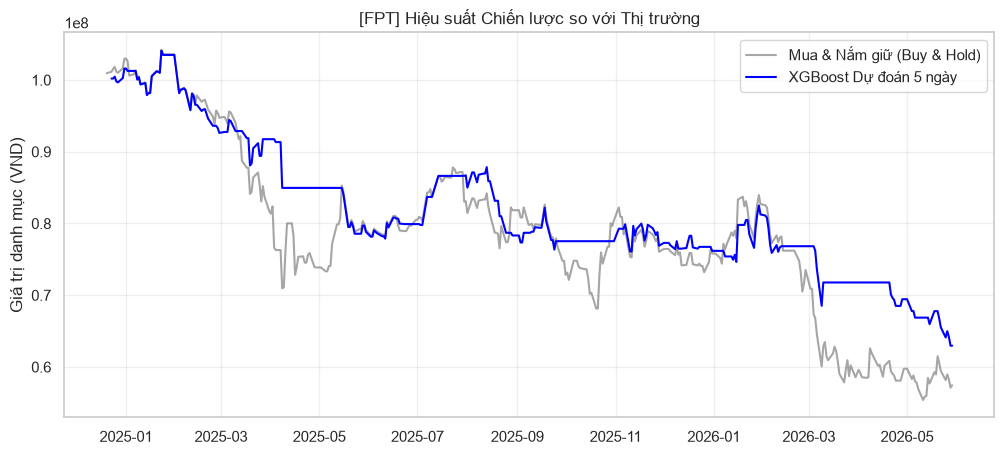

Đang thực hiện back testing trên HPG
Tổng lợi nhuận (Total Return): 5.56%
Sharpe Ratio: 0.37
Sụt giảm tối đa (Max Drawdown): -7.11%



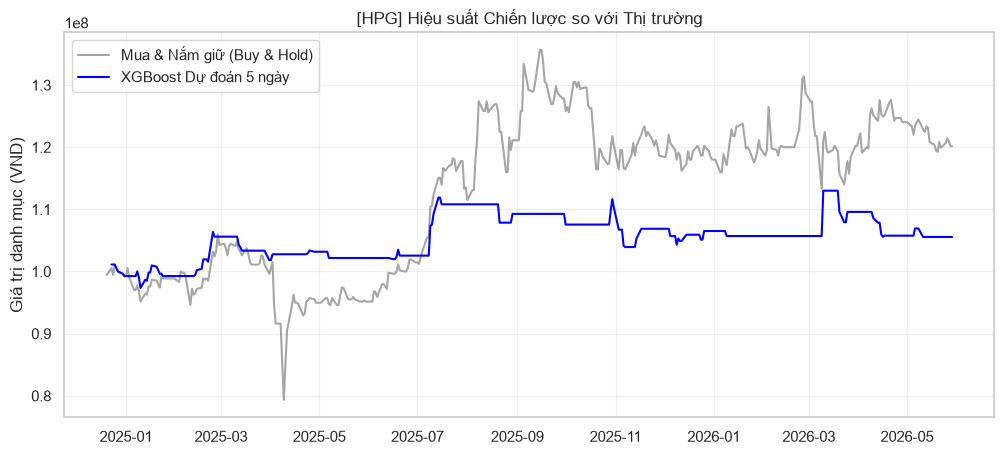

Đang thực hiện back testing trên VCB
Tổng lợi nhuận (Total Return): -32.84%
Sharpe Ratio: -0.62
Sụt giảm tối đa (Max Drawdown): -48.60%



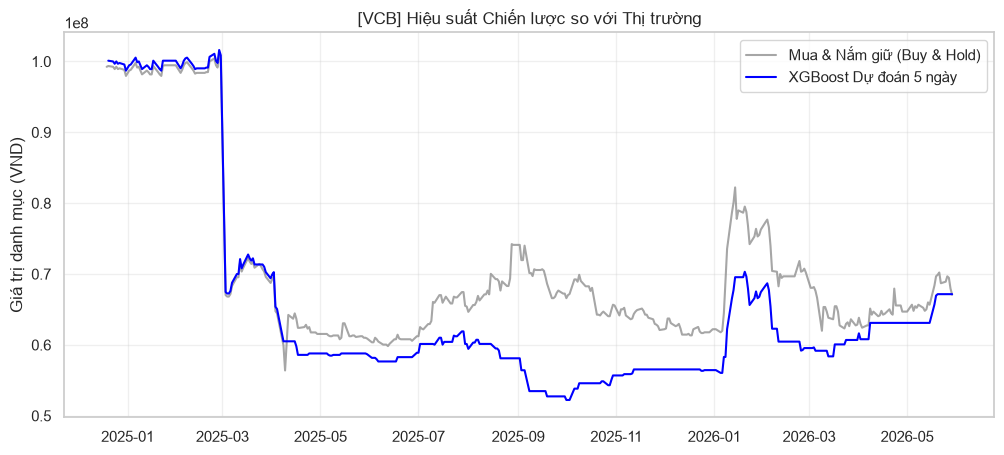

Đang thực hiện back testing trên TCB
Tổng lợi nhuận (Total Return): 22.00%
Sharpe Ratio: 0.74
Sụt giảm tối đa (Max Drawdown): -13.11%



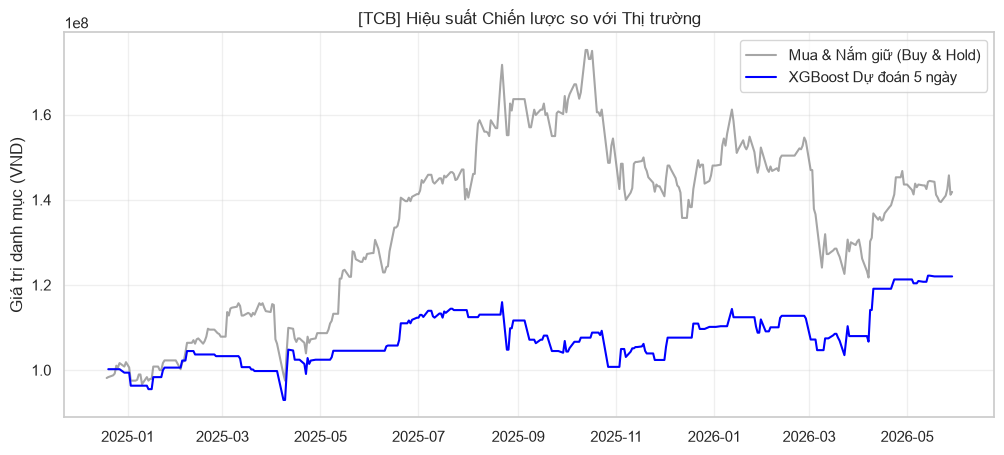

Đang thực hiện back testing trên MWG
Tổng lợi nhuận (Total Return): 8.00%
Sharpe Ratio: 0.44
Sụt giảm tối đa (Max Drawdown): -14.49%



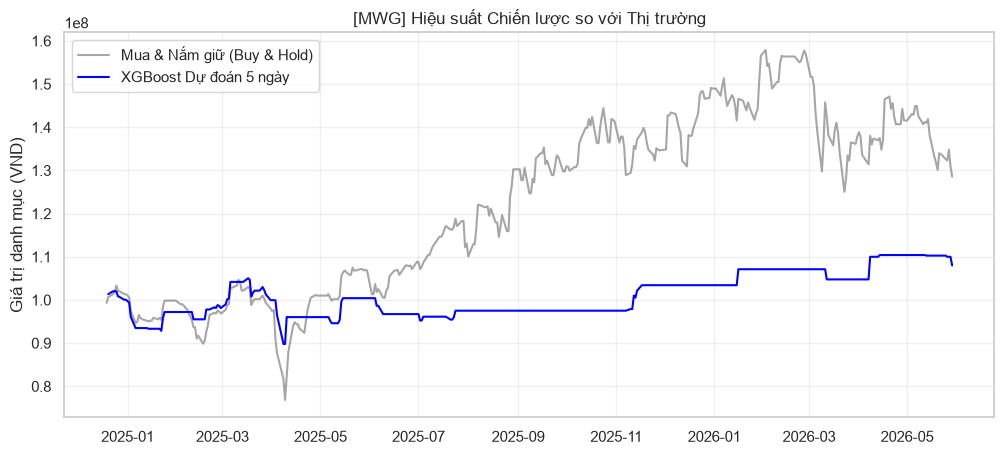

In [53]:
stock_codes = ['FPT', 'HPG', 'VCB', 'TCB', 'MWG']

feature_columns = [
        'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 
        'MACD', 'MACD_Signal', 'BB_Up', 'BB_Down', 'Volatility_20'
    ]

for code in stock_codes:
        
        technical_indicators = Technical_Indicators(data=data, close_col=f'{code}_Close')
        df_indicators = technical_indicators.build_all_indicators()
        
        strategy = MLStrategy(df_indicators)
        test_data_with_signal = strategy.run_xgboost(feature_cols=feature_columns)
        
        print(f'Đang thực hiện back testing trên {code}')
        
        back_testing = Back_Testing(test_data_with_signal, initial_capital=100000000)
        back_testing.run()
        back_testing.plot_results(code, label='XGBoost Dự đoán 5 ngày')

### Sarimax + Rolling Validation Stragety

In [35]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', UserWarning)

In [56]:
class SARIMAX_Rolling_Strategy:  # Đã sửa lỗi chính tả Stragety thành Strategy
    def __init__(self, data):
        self.data = data.copy()
    
    def run_model(self, exog_features, train_window=252, step=1):
        close_col = [c for c in self.data.columns if '_Close' in c][0]
        
        X = self.data[exog_features].copy()
        y = self.data[close_col].copy()
        
        # 1. XÁC ĐỊNH ĐIỂM CHIA TẬP TEST (20% cuối cùng của dữ liệu)
        # Tập Test độc lập sẽ bắt đầu từ vị trí test_start_idx trở đi
        test_start_idx = int(len(self.data) * 0.8)
        
        # Đảm bảo điểm bắt đầu tập Test phải lớn hơn train_window để có đủ dữ liệu học cuốn chiếu
        if test_start_idx < train_window:
            test_start_idx = train_window
            print(f"Cảnh báo: 80% dữ liệu quá nhỏ, tự động đẩy điểm bắt đầu Test về phiên {train_window}")

        signals = np.zeros(len(self.data))
        end_idx = len(self.data)
        
        print(f"Bắt đầu chạy SARIMAX Rolling trên tập TEST độc lập (từ phiên {test_start_idx} đến {end_idx})...")
        
        # 2. VÒNG LẶP CUỐN CHIẾU CHỈ CHẠY TRÊN TẬP TEST
        for i in range(test_start_idx, end_idx, step):
            pred_end = min(step + i, end_idx)
            
            # X_train lấy cửa sổ trượt 252 phiên ngay sát trước ngày hiện tại (i)
            X_train = X.iloc[i - train_window : i]
            y_train = y.iloc[i - train_window : i]
            
            # X_forecast lấy đoạn tương lai ngắn cần dự đoán
            X_forecast = X.iloc[i : pred_end]
            
            # Chuẩn hóa dữ liệu ngoại sinh độc lập để tránh rò rỉ dữ liệu (Data Leakage)
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_forecast_scaled = scaler.transform(X_forecast)
            
            # Khởi tạo và huấn luyện lại mô hình SARIMAX bằng dữ liệu cập nhật
            model = SARIMAX(
                endog=y_train, 
                exog=X_train_scaled, 
                order=(1, 1, 1), 
                enforce_stationarity=False, 
                enforce_invertibility=False
            )
            model_fit = model.fit(disp=False)
                
            # Dự đoán giá Close
            forecast = model_fit.forecast(steps=len(X_forecast), exog=X_forecast_scaled)
                
            # Tạo tín hiệu Mua (1) / Bán (0)
            current_price = y.iloc[i - 1]
            for idx, f_price in enumerate(forecast):
                if idx == 0:
                    signals[i + idx] = 1.0 if f_price > current_price else 0.0
                else:
                    signals[i + idx] = 1.0 if f_price > forecast.iloc[idx - 1] else 0.0
            
                    
        # TRÍCH XUẤT KẾT QUẢ ĐẦU RA CỦA RIÊNG TẬP TEST ĐỂ TRUYỀN VÀO BACKTESTER
        self.data['Signal'] = signals
        
        # Cắt riêng tập Test ra để tính hiệu suất tài khoản
        test_data = self.data.iloc[test_start_idx:].copy()
        test_data['Position'] = test_data['Signal'].diff()  
        test_data['Return'] = test_data[close_col].pct_change()
        test_data.dropna(subset=['Return'], inplace=True)
        
        return test_data

Bắt đầu chạy SARIMAX Rolling trên tập TEST độc lập (từ phiên 1504 đến 1880)...
Đang thực hiện back testing trên FPT
Tổng lợi nhuận (Total Return): -31.86%
Sharpe Ratio: -1.19
Sụt giảm tối đa (Max Drawdown): -39.18%



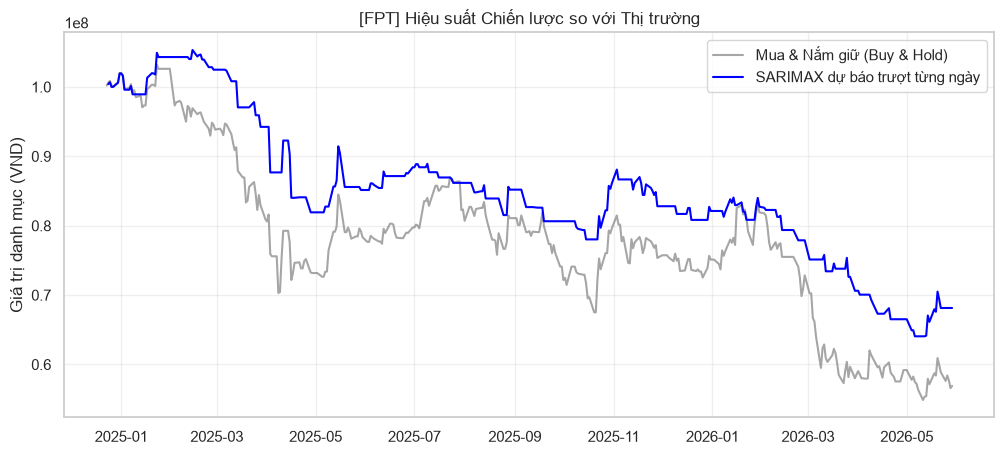

Bắt đầu chạy SARIMAX Rolling trên tập TEST độc lập (từ phiên 1504 đến 1880)...
Đang thực hiện back testing trên HPG
Tổng lợi nhuận (Total Return): 27.25%
Sharpe Ratio: 0.93
Sụt giảm tối đa (Max Drawdown): -10.02%



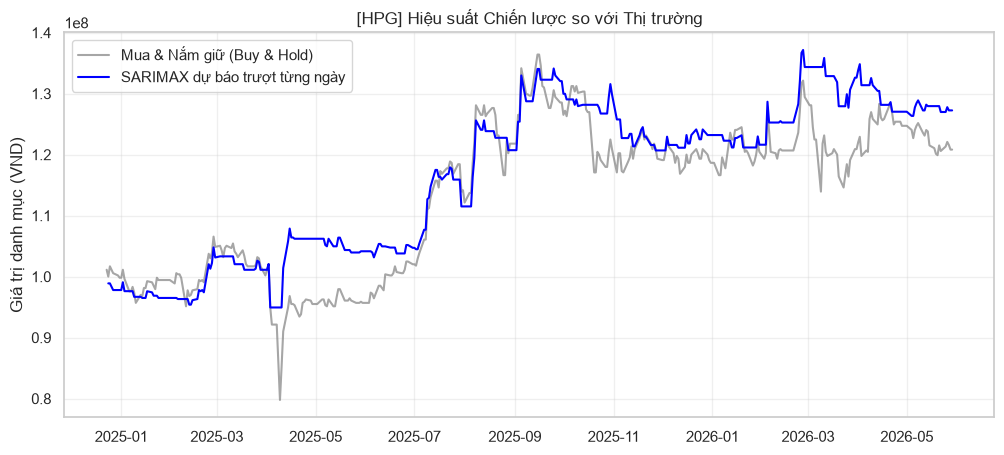

Bắt đầu chạy SARIMAX Rolling trên tập TEST độc lập (từ phiên 1496 đến 1871)...


d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result 

Đang thực hiện back testing trên VCB
Tổng lợi nhuận (Total Return): -24.24%
Sharpe Ratio: -0.36
Sụt giảm tối đa (Max Drawdown): -34.54%



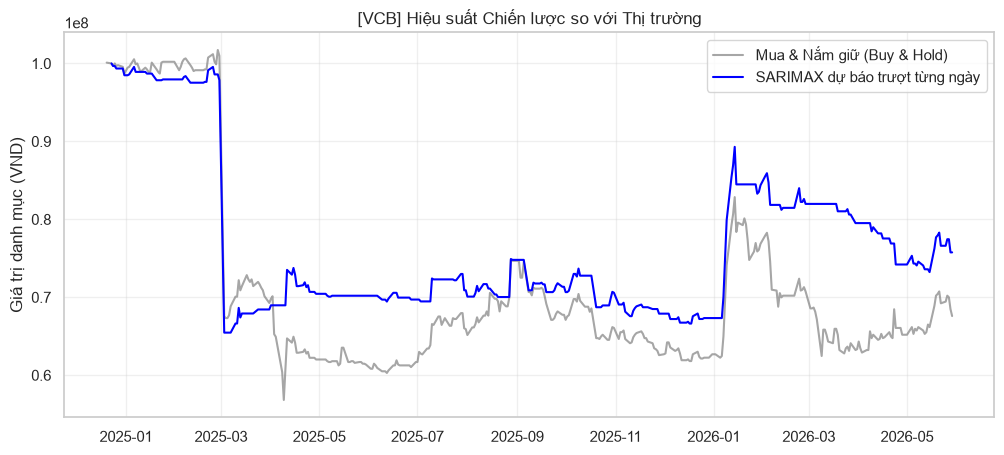

Bắt đầu chạy SARIMAX Rolling trên tập TEST độc lập (từ phiên 1496 đến 1871)...


d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result 

Đang thực hiện back testing trên TCB
Tổng lợi nhuận (Total Return): 26.84%
Sharpe Ratio: 0.77
Sụt giảm tối đa (Max Drawdown): -20.81%



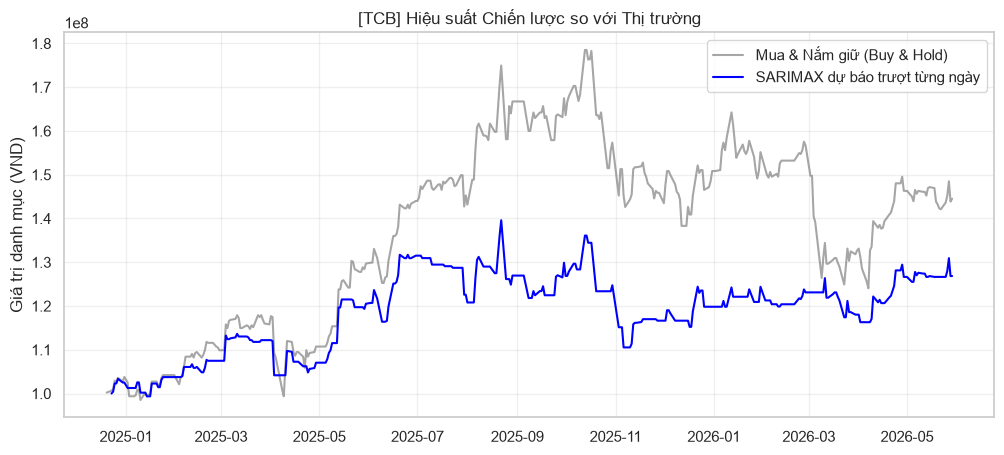

Bắt đầu chạy SARIMAX Rolling trên tập TEST độc lập (từ phiên 1496 đến 1871)...


d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\StockPrice\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result 

Đang thực hiện back testing trên MWG
Tổng lợi nhuận (Total Return): 27.37%
Sharpe Ratio: 0.86
Sụt giảm tối đa (Max Drawdown): -14.46%



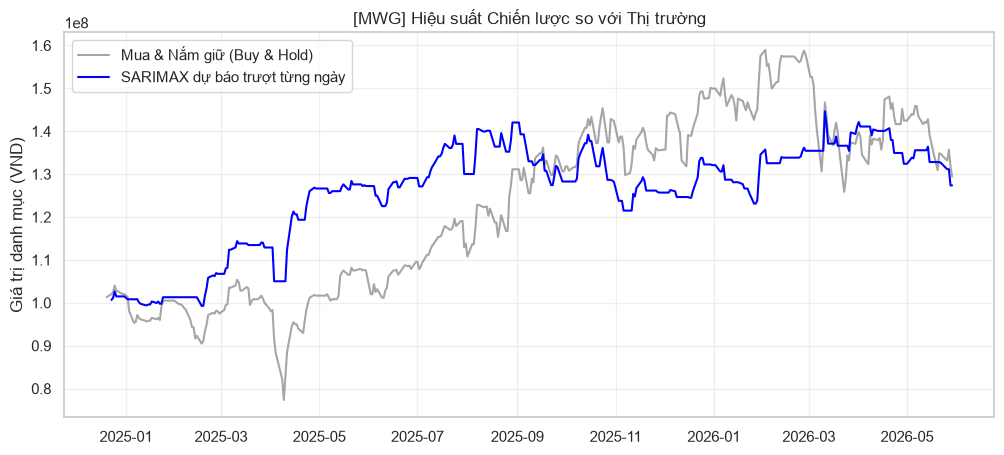

In [58]:
stock_codes = ['FPT', 'HPG', 'VCB', 'TCB', 'MWG']

feature_columns = [
        'SMA_20', 'SMA_50', 'EMA_20', 'RSI_14', 
        'MACD', 'MACD_Signal', 'BB_Up', 'BB_Down', 'Volatility_20'
    ]

for code in stock_codes:
        
        technical_indicators = Technical_Indicators(data=data, close_col=f'{code}_Close')
        df_indicators = technical_indicators.build_all_indicators()
        
        sarimax_stragety = SARIMAX_Rolling_Strategy(df_indicators)
        test_data_with_signal = sarimax_stragety.run_model(exog_features=feature_columns, train_window=255, step=5)
        
        print(f'Đang thực hiện back testing trên {code}')
        
        back_testing = Back_Testing(test_data_with_signal, initial_capital=100000000)
        back_testing.run()
        back_testing.plot_results(code, label='SARIMAX dự báo trượt từng ngày')